# 04 — Final Training and Evaluation

This notebook retrains the U-Net configuration selected in Notebook 03 using the same Adam optimizer, MSE objective, learning-rate scheduling and early stopping. Only the **training** split updates model weights; **validation** loss controls scheduling and checkpoint selection. The saved best checkpoint is then evaluated on **test** data.

Evaluation compares magnitude-spectrogram MSE against the unchanged noisy input and includes a short listening example. Run from `notebooks/` in the project environment.


In [3]:
import sys

sys.path.append('../')

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from torch.utils.data import DataLoader

from src.training import train_model
from src.models.model_unet import UNet
from src.dataprocess.torch_dataset_SNSD import DenoisingSpectrogramDataset

DATA_DIR = '/media/gabriel/500 BKP/datasets/SNSD-DataSet/preprocessed'
CHECKPOINTS_DIR = os.path.abspath('../tuning/checkpoints/final_training')
TARGET_FRAMES = 1024
np.random.seed(42)
torch.manual_seed(42)


## 1. Selected configuration and paired inputs

Read the configuration with the lowest finite validation loss from the exported Optuna results. No test score is used to choose hyperparameters.

For this run, both members of each pair use the first 1,024 frames (approximately eight seconds), with zero padding on the right when needed.

In [4]:
study = pd.read_csv('../tuning/optuna_trials.csv')
study['val_loss'] = pd.to_numeric(study['val_loss'], errors='coerce')
study = study[np.isfinite(study['val_loss'])].sort_values('val_loss')
if study.empty:
    raise ValueError('No finite validation losses in the trial CSV.')
best_params = study.iloc[0]
display(best_params)

trial                                                          13
val_loss                                                 0.011548
model_path      /home/gabriel/VSProjects/audio_analysis/Denois...
base_filters                                                   32
depth                                                           4
dropout_rate                                             0.004557
lr                                                       0.000401
batch_size                                                      8
Name: 0, dtype: object

## 2. Training with validation-based early stopping

Train for up to 100 epochs, reduce the learning rate after two validation-loss plateaus, and stop after five epochs without improvement. Audio previews during training are disabled to keep the output concise; listening is performed after loading the selected checkpoint.


In [8]:
# Best Hyperparameters
base_filters = int(best_params['base_filters'])
depth = int(best_params['depth'])
dropout_rate = float(best_params['dropout_rate'])
lr = float(best_params['lr'])
batch_size = int(best_params['batch_size'])

# Dataset
TARGET_FRAMES = 1024
train_dataset = DenoisingSpectrogramDataset(DATA_DIR, 'train', TARGET_FRAMES)
val_dataset = DenoisingSpectrogramDataset(DATA_DIR, 'validation', TARGET_FRAMES)

if len(train_dataset) == 0 or len(val_dataset) == 0:
    raise ValueError('Training or validation split is empty; check DATA_DIR.')

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, persistent_workers=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, persistent_workers=False)

In [3]:
# Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = UNet(
    in_channels=1,
    out_channels=1,
    base_filters=base_filters,
    depth=depth,
    dropout_rate=dropout_rate
).to(device)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=2)
criterion = torch.nn.MSELoss()

# Train
model, train_losses, val_losses, best_val_loss = train_model(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=device,
    train_loader=train_loader,
    train_dataset=train_dataset,
    val_loader=val_loader,
    val_dataset=val_dataset,
    num_epochs=100,
    early_stopping_patience=5,
    audio_preview=False,
    save_dir=CHECKPOINTS_DIR,
    log_to_wandb = False
)

Using device: cuda

Epoch 1/100


Best model saved: /home/gabriel/VSProjects/audio_analysis/DenoisingAutoencoder/tuning/checkpoints/final_training/model_trial_default.pth (val loss: 0.0247)
Train Loss: 0.0405 | Val Loss: 0.0247
Learning Rate: 0.000401

Epoch 2/100


Best model saved: /home/gabriel/VSProjects/audio_analysis/DenoisingAutoencoder/tuning/checkpoints/final_training/model_trial_default.pth (val loss: 0.0237)
Train Loss: 0.0179 | Val Loss: 0.0237
Learning Rate: 0.000401

Epoch 3/100


No improvement for 1 epoch(s)
Train Loss: 0.0144 | Val Loss: 0.0410
Learning Rate: 0.000401

Epoch 4/100


Best model saved: /home/gabriel/VSProjects/audio_analysis/DenoisingAutoencoder/tuning/checkpoints/final_training/model_trial_default.pth (val loss: 0.0163)
Train Loss: 0.0133 | Val Loss: 0.0163
Learning Rate: 0.000401

Epoch 5/100


...

No improvement for 1 epoch(s)
Train Loss: 0.0070 | Val Loss: 0.0127
Learning Rate: 0.000040

Epoch 13/100


No improvement for 2 epoch(s)
Train Loss: 0.0069 | Val Loss: 0.0134
Learning Rate: 0.000040

Epoch 14/100


No improvement for 3 epoch(s)
Train Loss: 0.0067 | Val Loss: 0.0128
Learning Rate: 0.000004

Epoch 15/100


No improvement for 4 epoch(s)
Train Loss: 0.0066 | Val Loss: 0.0127
Learning Rate: 0.000004

Epoch 16/100


No improvement for 5 epoch(s)
Early stopping triggered.


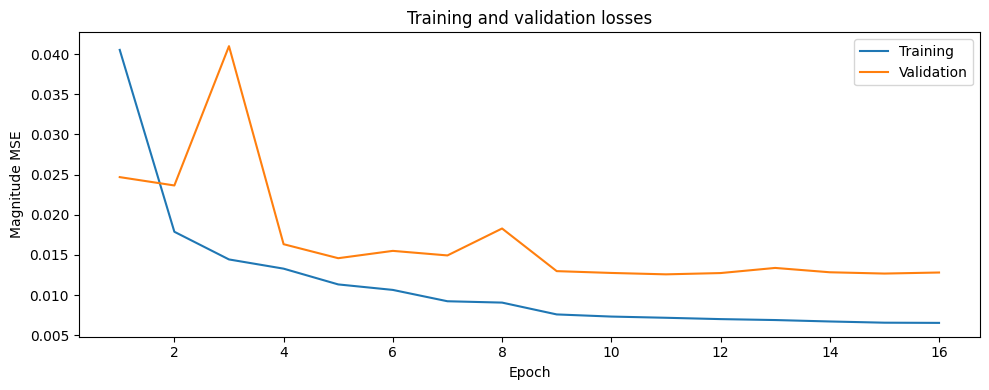

Best validation loss: 0.012585


In [4]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 4))
plt.plot(epochs, train_losses, label='Training')
plt.plot(epochs, val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Magnitude MSE')
plt.title('Training and validation losses')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Best validation loss: {best_val_loss:.6f}')

**After running:** briefly describe convergence and any gap between the training and validation curves. These curves use the existing training helper's average of batch losses.

## 3. Final test evaluation

The training helper saves the best validation checkpoint but returns the model from the last epoch. Reload the saved weights before evaluating. Test data is introduced only here, after training and model selection.

Compare the raw model prediction against the noisy-input baseline using linear-magnitude MSE. Each pair receives equal weight, including a smaller final batch; padded bins are included. Positive relative reduction means lower average error. MSE measures spectral reconstruction accuracy, not perceived speech quality. Keep the model fixed after inspecting test results; this procedure does not undo any earlier use of the same test data for model selection.


In [10]:
if  "model" not in globals():

    import torch
    from src.models.model_unet import UNet

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Use the exact architecture settings from the saved training run.
    model = UNet(
        in_channels=1,
        out_channels=1,
        base_filters=base_filters,
        depth=depth,
        dropout_rate=dropout_rate,
    ).to(device)

    checkpoint_path = "../tuning/checkpoints/final_training/model_trial_default.pth"

    state_dict = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True,
    )
    model.load_state_dict(state_dict)
    model.eval()

else:
    checkpoint_path = os.path.join(CHECKPOINTS_DIR, 'model_trial_default.pth')
    model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
    model.eval()

In [11]:
test_dataset = DenoisingSpectrogramDataset(DATA_DIR, 'test', TARGET_FRAMES)
if len(test_dataset) == 0:
    raise ValueError('Test split is empty; check DATA_DIR.')
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

noisy_errors, model_errors = [], []
with torch.inference_mode():
    for noisy, clean in test_loader:
        noisy = noisy.unsqueeze(1).to(device)
        clean = clean.unsqueeze(1).to(device)
        prediction = model(noisy)
        noisy_errors.extend((noisy - clean).square().mean((1, 2, 3)).cpu().tolist())
        model_errors.extend((prediction - clean).square().mean((1, 2, 3)).cpu().tolist())

baseline_mse = float(np.mean(noisy_errors))
test_mse = float(np.mean(model_errors))
reduction = 100 * (1 - test_mse / baseline_mse) if baseline_mse > 0 else float('nan')
display(pd.DataFrame({'Mean test MSE': [baseline_mse, test_mse]},
                     index=['Noisy input', 'U-Net prediction']))
print(f'Relative MSE reduction: {reduction:.2f}%')


,Mean test MSE
Noisy input,0.054358
U-Net prediction,0.013243


Relative MSE reduction: 75.64%


## 4. Spectrograms and listening

Inspect a a few test samples. All three signals below are reconstructed from magnitude using Griffin–Lim, including the clean reference; they are not the original waveforms. Artifacts can therefore arise from both the predicted magnitude and estimated phase.

The plots share a dB reference and the players share one gain. Negative model outputs are clipped to zero only for reconstruction and visualization; test MSE above uses the unmodified output.


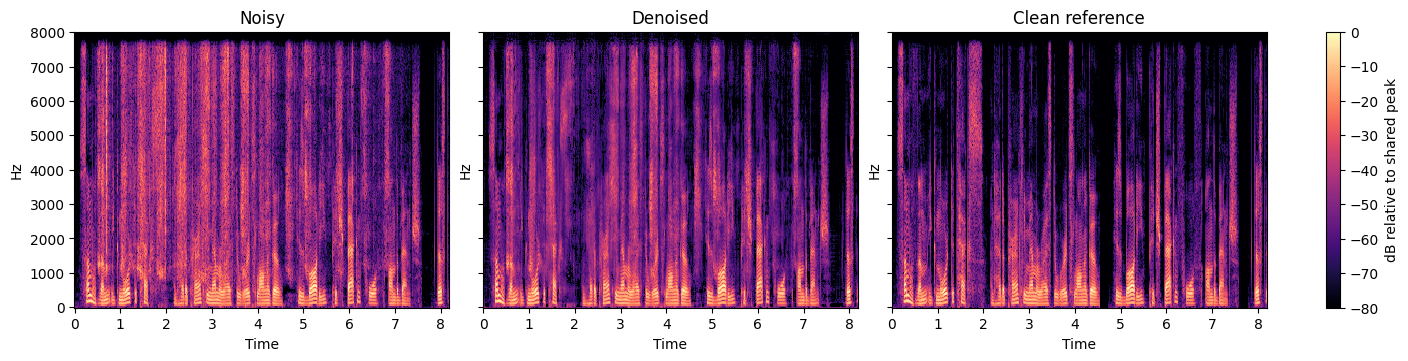

Noisy (Griffin–Lim reconstruction)


Denoised (Griffin–Lim reconstruction)


Clean reference (Griffin–Lim reconstruction)


In [19]:
import librosa
import librosa.display
from IPython.display import Audio


# Examples:

# index = 0 : Door slam, Good Reconstruction
# index = 5 : Chatter, Good Reconstruction
# index = 25 : Loud Chatter, Reasonable Reconstruction
# index = 87 : Machine Buzz, Good Reconstruction
# index = 97 : Loud Eating Noise, Poor Reconstruction - Not much noise removed

SAMPLE_INDEX = 97  # Change to inspect other test pairs.
noisy, clean = test_dataset[SAMPLE_INDEX]
with torch.inference_mode():
    predicted = model(noisy[None, None].to(device))[0, 0].cpu().numpy()

magnitudes = [noisy.numpy(), np.maximum(predicted, 0), clean.numpy()]
labels = ['Noisy', 'Denoised', 'Clean reference']
reference = max(float(x.max()) for x in magnitudes) or 1.0
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True, constrained_layout=True)
for ax, magnitude, label in zip(axes, magnitudes, labels):
    db = librosa.amplitude_to_db(magnitude, ref=reference, top_db=None)
    image = librosa.display.specshow(db, sr=16000, hop_length=128,
                                    x_axis='time', y_axis='linear', ax=ax,
                                    vmin=-80, vmax=0)
    ax.set_title(label)
fig.colorbar(image, ax=axes, label='dB relative to shared peak')
plt.show()

audio = [librosa.griffinlim(x, n_iter=64, hop_length=128, win_length=512,
                           random_state=42) for x in magnitudes]
gain = 0.95 / max(max(float(np.abs(x).max()) for x in audio), 1e-8)
for label, waveform in zip(labels, audio):
    print(label + ' (Griffin–Lim reconstruction)')
    display(Audio(waveform * gain, rate=16000, normalize=False))


## 5. Conclusions

The selected U-Net reduced mean test-set magnitude MSE from **0.054358** for the noisy input to **0.013243**, a **75.64% reduction**. This demonstrates improved reconstruction of clean magnitude spectrograms relative to leaving the noisy input unchanged.

Training stopped after 16 epochs, with the best validation loss of **0.012585** reached at epoch 11. Training loss continued to decrease while validation performance plateaued, supporting the use of early stopping and the best validation checkpoint for evaluation.

The inspected examples were judged to give good reconstruction for door-slam noise and chatter, with a less successful result under loud chatter. These examples illustrate variation across noise conditions, but do not establish performance across entire noise categories.

Lower spectrogram MSE does not necessarily imply better perceived quality or intelligibility. The model predicts magnitude only, and Griffin–Lim phase estimation can introduce artifacts independently of the network. Because the clean reference is also reconstructed with Griffin–Lim, it is not an artifact-free listening reference.

Overall, the experiment demonstrates an end-to-end speech-denoising workflow combining time-frequency representations, supervised U-Net training and waveform reconstruction. Its conclusions remain limited to the evaluated dataset and fixed-length excerpts.
